# 06. Customizing and Annotating Visualizations

## For Presentations

## 📚 Learning Objectives

By completing this notebook, you will:
- Customize visualizations (colors, fonts, styles)
- Add annotations (text, arrows, highlights)
- Format charts for professional presentations
- Use consistent styling and themes
- Export publication-quality plots

## 🔗 Where this fits

**Builds on:** Course 05 — Unit 3, lesson 02 "Matplotlib Fundamentals" — the axes object is what annotations, colours and themes attach to.

**Used later in:** Course 05 — Unit 3, lesson 07, which asks which of these choices actually help the reader.

---

This notebook covers practical activities from **Course 05, Unit 3**:
- Customizing and annotating visualizations for presentations

---

## The Story: Polishing Your Work

Imagine you've written a report (created a chart). **Before** presenting, you polish it - add formatting, highlight key points, make it professional. **After** polishing, your work is presentation-ready!

Same with visualization: **After** creating basic charts, we customize - add colors, fonts, annotations. **After** customizing, charts are professional and presentation-ready!

---

## Why Customization and Annotation Matter

Customization and annotation are essential because:
- **Clarity**: Clear charts communicate better
- **Professionalism**: Well-designed charts impress
- **Insights**: Annotations highlight key findings
- **Consistency**: Consistent styling creates cohesive presentations

**Common Student Questions:**
- **Q: What should I customize?**
  - Answer: Colors, fonts, labels, titles, legends, grid
  - Example: Use consistent colors, readable fonts, clear labels
  - Tip: Less is more - don't over-customize!
  
- **Q: When do I add annotations?**
  - Answer: To highlight important points, explain outliers, show trends
  - Example: Arrow pointing to peak, text explaining spike
  - Benefit: Annotations guide viewer's attention

---

## Introduction

**Customizing and annotating visualizations** transforms basic charts into professional, presentation-ready visualizations. Proper customization enhances clarity, while annotations highlight key insights.


## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- **Real data:** `montgomery_911_calls.csv` — 663,522 real 911 dispatches in
  Montgomery County, Pennsylvania (Dec 2015 – Jul 2020). We chart the 2018
  monthly call volume against the 2017 monthly average as a benchmark line.
- matplotlib, seaborn, pandas

**Outputs:** What you'll see when you run the cells

- The same real series drawn four ways: styled, annotated, highlighted, publication-ready
- A peak annotation and per-month markers computed from the data, never hard-coded

---


In [1]:
# WHAT: Import libraries, set a professional style, and load the real series we will style.
# WHY: Customization is best learned on ONE honest series - the techniques, not the numbers, are the lesson.

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Set professional style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("✅ Libraries imported!")
print("\n" + "=" * 70)
print("Customizing and Annotating Visualizations")
print("=" * 70)

# ============================================================================
# ============================================================================
print("-" * 70)

DATA_DIR = '../../../Course 04/datasets/raw/'

# Real data: the Montgomery County (PA) 911 dispatch log.
calls = pd.read_csv(DATA_DIR + 'montgomery_911_calls.csv',
                    usecols=['timeStamp'], parse_dates=['timeStamp'])

# 2018 monthly call volume - the series we will style and annotate.
y2018 = calls[(calls['timeStamp'] >= '2018-01-01') & (calls['timeStamp'] < '2019-01-01')]
monthly = y2018.groupby(y2018['timeStamp'].dt.month).size()

# Benchmark line: the 2017 monthly average. A real reference point, not an invented target.
y2017 = calls[(calls['timeStamp'] >= '2017-01-01') & (calls['timeStamp'] < '2018-01-01')]
baseline_2017 = y2017.groupby(y2017['timeStamp'].dt.month).size().mean()

MONTH_NAMES = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
data = pd.DataFrame({
    'month': MONTH_NAMES,
    'calls': monthly.reindex(range(1, 13)).values,
    'baseline': [baseline_2017] * 12,
})

print(f"Real 2018 monthly 911 call volume (benchmark = 2017 monthly average "
      f"= {baseline_2017:,.0f} calls):")
print(data.round(0).to_string(index=False))

✅ Libraries imported!

Customizing and Annotating Visualizations
----------------------------------------------------------------------


Real 2018 monthly 911 call volume (benchmark = 2017 monthly average = 11,695 calls):
month  calls  baseline
  Jan  13123   11695.0
  Feb  11165   11695.0
  Mar  14923   11695.0
  Apr  11240   11695.0
  May  12551   11695.0
  Jun  12106   11695.0
  Jul  12549   11695.0
  Aug  12315   11695.0
  Sep  12338   11695.0
  Oct  12976   11695.0
  Nov  14097   11695.0
  Dec  12144   11695.0



PART 2: Customization

✅ Example 1: Colors and Styles
----------------------------------------------------------------------


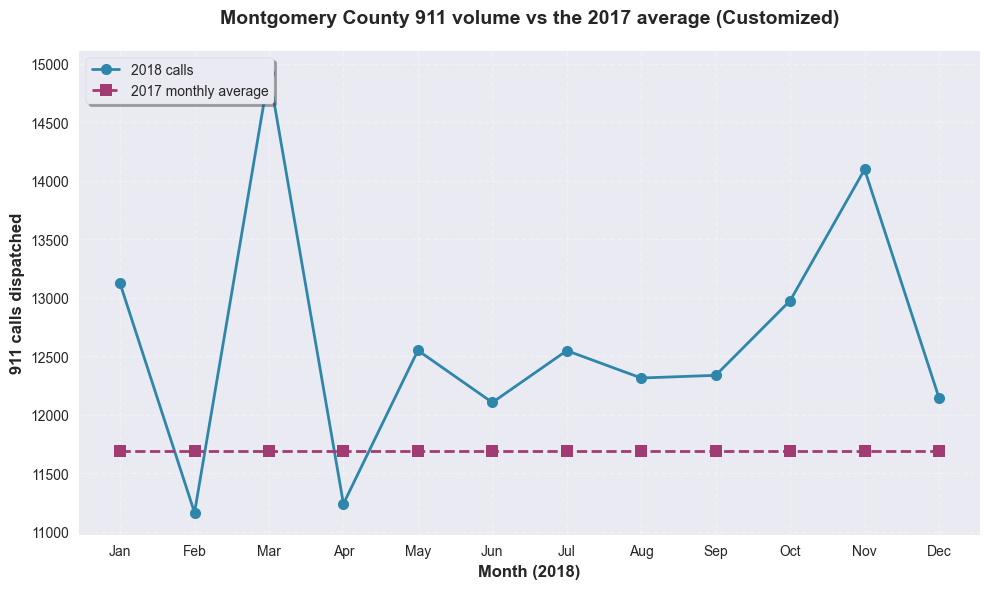

💡 Customized: Colors, fonts, line styles, grid, legend

✅ Example 2: Professional Styling comes next - see the bar chart below


In [2]:
# WHAT: Style the real 2018 call series - colours, line styles, fonts, grid and legend.
# WHY: Defaults communicate nothing; deliberate styling is what makes a chart readable at a glance.

# ============================================================================
# PART 2: CUSTOMIZATION
# ============================================================================
print("\n" + "=" * 70)
print("PART 2: Customization")
print("=" * 70)

# Example 1: Colors and Styles
print("\n✅ Example 1: Colors and Styles")
print("-" * 70)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(data['month'], data['calls'], marker='o', linewidth=2,
        markersize=8, color='#2E86AB', label='2018 calls', linestyle='-')
ax.plot(data['month'], data['baseline'], marker='s', linewidth=2,
        markersize=8, color='#A23B72', label='2017 monthly average', linestyle='--')
ax.set_xlabel('Month (2018)', fontsize=12, fontweight='bold')
ax.set_ylabel('911 calls dispatched', fontsize=12, fontweight='bold')
ax.set_title('Montgomery County 911 volume vs the 2017 average (Customized)',
             fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper left', fontsize=10, frameon=True, shadow=True)
ax.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()
print("💡 Customized: Colors, fonts, line styles, grid, legend")

print("\n✅ Example 2: Professional Styling comes next - see the bar chart below")

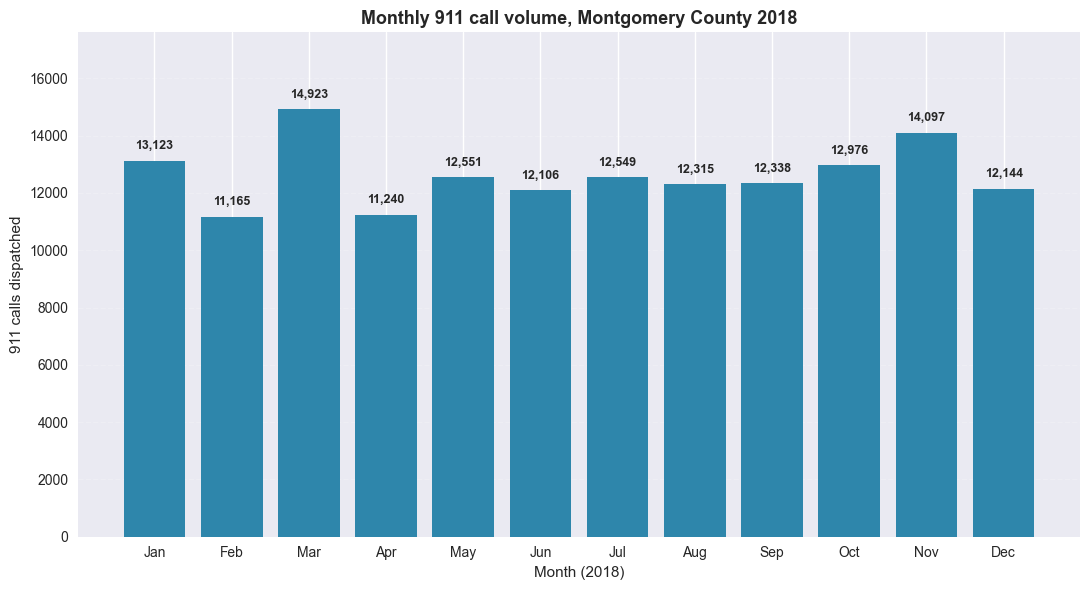

💡 Professional: Consistent colors, value labels, clean design

PART 3: Annotations

✅ Example 3: Text Annotations
----------------------------------------------------------------------


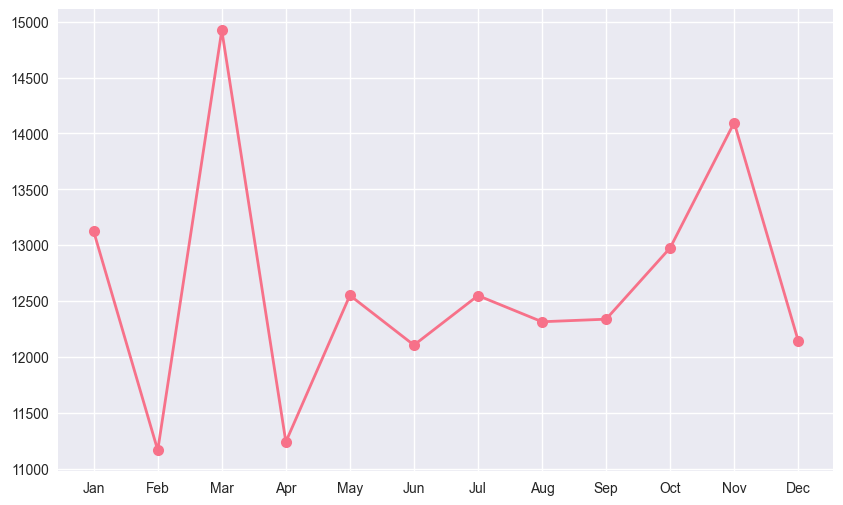

In [3]:
# WHAT: Draw a styled bar chart of the real monthly volume - custom colors, labels, grid, and value annotations.
# WHY: Titles, axis labels, and direct value labels are the difference between a draft and a chart you can present.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Data from previous section (reloaded so this cell also runs standalone)
DATA_DIR = '../../../Course 04/datasets/raw/'

# Real data: the Montgomery County (PA) 911 dispatch log.
calls = pd.read_csv(DATA_DIR + 'montgomery_911_calls.csv',
                    usecols=['timeStamp'], parse_dates=['timeStamp'])

# 2018 monthly call volume - the series we will style and annotate.
y2018 = calls[(calls['timeStamp'] >= '2018-01-01') & (calls['timeStamp'] < '2019-01-01')]
monthly = y2018.groupby(y2018['timeStamp'].dt.month).size()

# Benchmark line: the 2017 monthly average. A real reference point, not an invented target.
y2017 = calls[(calls['timeStamp'] >= '2017-01-01') & (calls['timeStamp'] < '2018-01-01')]
baseline_2017 = y2017.groupby(y2017['timeStamp'].dt.month).size().mean()

MONTH_NAMES = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
data = pd.DataFrame({
    'month': MONTH_NAMES,
    'calls': monthly.reindex(range(1, 13)).values,
    'baseline': [baseline_2017] * 12,
})

# Create figure for plotting
fig, ax = plt.subplots(figsize=(11, 6))

bars = ax.bar(data['month'], data['calls'], color='#2E86AB')
ax.set_xlabel('Month (2018)', fontsize=11)
ax.set_ylabel('911 calls dispatched', fontsize=11)
ax.set_title('Monthly 911 call volume, Montgomery County 2018',
             fontsize=13, fontweight='bold')
ax.set_ylim(0, data['calls'].max() * 1.18)
ax.grid(True, alpha=0.2, axis='y', linestyle='--')

# Add value labels on bars - read straight from the data, never typed by hand
for i, (month, n) in enumerate(zip(data['month'], data['calls'])):
    ax.text(i, n + data['calls'].max() * 0.02, f'{n:,}',
            ha='center', va='bottom', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()
print("💡 Professional: Consistent colors, value labels, clean design")

# ============================================================================
# PART 3: ANNOTATIONS
# ============================================================================
print("\n" + "=" * 70)
print("PART 3: Annotations")
print("=" * 70)

# Example 3: Text Annotations
print("\n✅ Example 3: Text Annotations")
print("-" * 70)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(data['month'], data['calls'], marker='o', linewidth=2, markersize=8)

In [4]:
# WHAT: Find the busiest month in the real log and annotate it with an arrow and a label.
# WHY: The callout text is computed from the data, so it stays true if the data is updated.

# Find the busiest month in the real 2018 log
peak_idx = data['calls'].idxmax()
peak_month = data.loc[peak_idx, 'month']
peak_value = data.loc[peak_idx, 'calls']

# Annotate peak
ax.annotate(f'Busiest month: {peak_month} ({peak_value:,} calls)',
            xy=(peak_idx, peak_value),
            xytext=(max(peak_idx - 4.5, 0.2), peak_value + data['calls'].max() * 0.05),
            arrowprops=dict(arrowstyle='->', color='red', lw=2),
            fontsize=11, fontweight='bold', color='red',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7))

ax.set_xlabel('Month (2018)', fontsize=11)
ax.set_ylabel('911 calls dispatched', fontsize=11)
ax.set_title('2018 call volume with the peak annotated', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print(f"💡 Annotations: Highlight key points, explain patterns "
      f"(peak read from the data: {peak_month})")

# Example 1: Multiple Annotations
print("\n✅ Example 1: Multiple Annotations")
print("-" * 70)

<Figure size 800x550 with 0 Axes>

💡 Annotations: Highlight key points, explain patterns (peak read from the data: Mar)

✅ Example 1: Multiple Annotations
----------------------------------------------------------------------


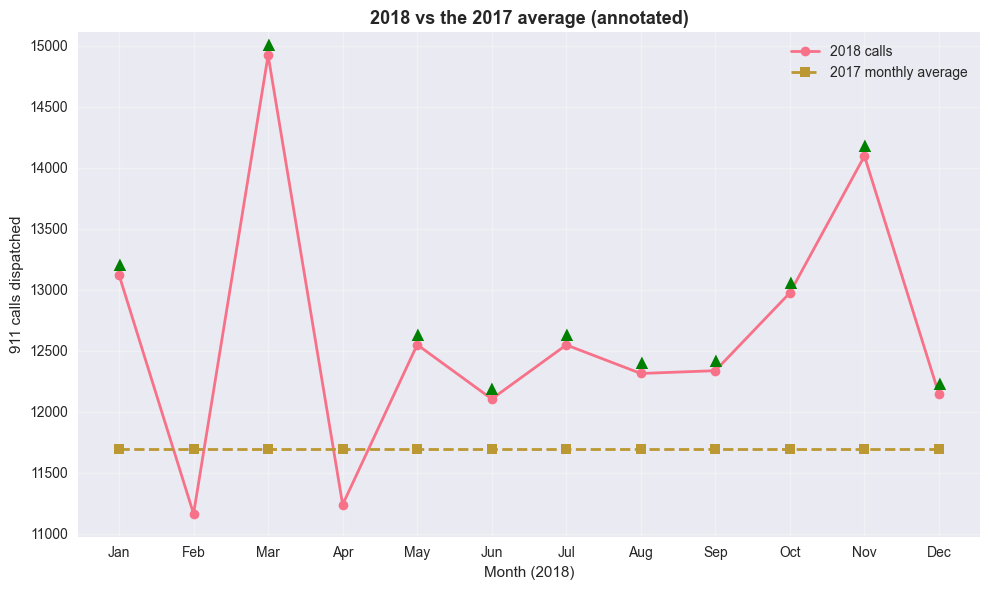

💡 Multiple annotations: 10 of 12 months in 2018 ran above the 2017 monthly average of 11,695 calls


In [5]:
# WHAT: Plot 2018 volume against the 2017 average and mark every month that ran above it.
# WHY: Conditional annotations draw the eye exactly to the story - here, the months busier than 2017.

# Data from previous section (reloaded so this cell also runs standalone)
import pandas as pd
import numpy as np
DATA_DIR = '../../../Course 04/datasets/raw/'

# Real data: the Montgomery County (PA) 911 dispatch log.
calls = pd.read_csv(DATA_DIR + 'montgomery_911_calls.csv',
                    usecols=['timeStamp'], parse_dates=['timeStamp'])

# 2018 monthly call volume - the series we will style and annotate.
y2018 = calls[(calls['timeStamp'] >= '2018-01-01') & (calls['timeStamp'] < '2019-01-01')]
monthly = y2018.groupby(y2018['timeStamp'].dt.month).size()

# Benchmark line: the 2017 monthly average. A real reference point, not an invented target.
y2017 = calls[(calls['timeStamp'] >= '2017-01-01') & (calls['timeStamp'] < '2018-01-01')]
baseline_2017 = y2017.groupby(y2017['timeStamp'].dt.month).size().mean()

MONTH_NAMES = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
data = pd.DataFrame({
    'month': MONTH_NAMES,
    'calls': monthly.reindex(range(1, 13)).values,
    'baseline': [baseline_2017] * 12,
})

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(data['month'], data['calls'], marker='o', linewidth=2, label='2018 calls')
ax.plot(data['month'], data['baseline'], marker='s', linewidth=2,
        label='2017 monthly average', linestyle='--')

above = 0
for i, (month, n, base) in enumerate(zip(data['month'], data['calls'], data['baseline'])):
    if n > base:
        above += 1
        ax.annotate('▲', xy=(i, n), fontsize=13, color='green',
                    ha='center', va='bottom')  # triangle = above the 2017 average

ax.set_xlabel('Month (2018)', fontsize=11)
ax.set_ylabel('911 calls dispatched', fontsize=11)
ax.set_title('2018 vs the 2017 average (annotated)', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print(f"💡 Multiple annotations: {above} of 12 months in 2018 ran above the "
      f"2017 monthly average of {data['baseline'].iloc[0]:,.0f} calls")

## Part 4: Presentation Quality

A checklist before any chart goes into a presentation or report:

1. **High resolution** — save with `dpi=300` for print; prefer vector formats
   (PDF, SVG) when possible; make sure all text is readable
2. **Consistent styling** — one color palette, consistent fonts and sizes,
   uniform chart style across the whole deck
3. **Clear labels** — descriptive axis labels, informative titles, clear legend
4. **Professional appearance** — clean uncluttered design, deliberate white
   space, balanced layout

The next cell applies all four points to build a publication-quality plot:

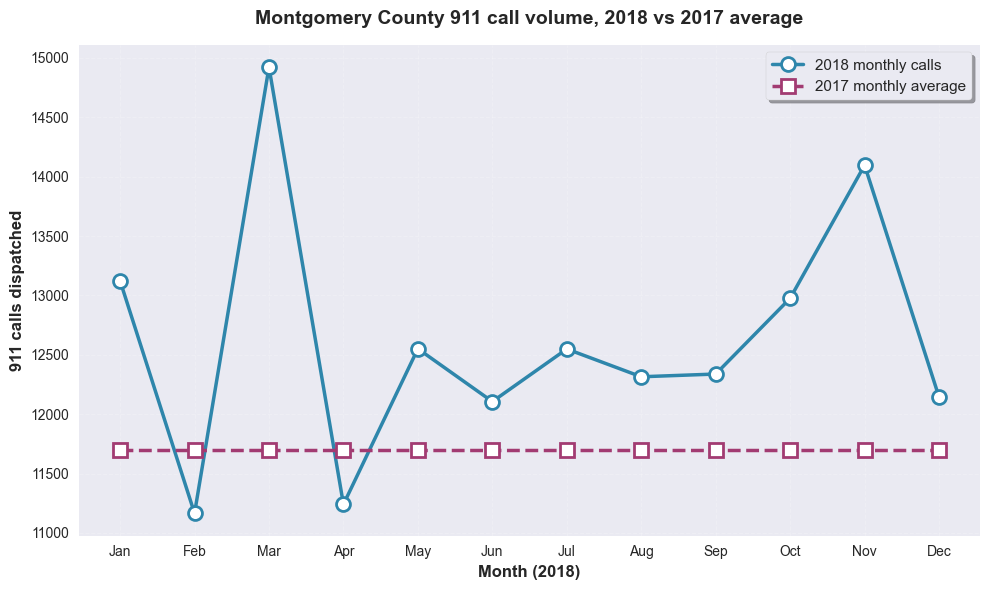

💡 Publication-quality: High resolution, professional styling, clean design
   Total 2018 calls charted: 151,527

Summary

✅ What you learned:
   1. Customization: Colors, fonts, styles, grid, legends
   2. Annotations: peak callouts and conditional markers, both computed from the data
   3. Presentation quality: resolution, spines, muted grid, direct value labels

🎯 Rule of thumb: every number printed on a chart should be READ from the data,
   never typed in by hand - that is how charts stay true after the data updates.

📚 Next Steps:
   - Example 07: Visualization Best Practices

✅ Customization and annotation - complete!


In [6]:
# WHAT: Produce the publication-quality version of the same real chart.
# WHY: High resolution, muted grid, no top/right spines - the details reviewers notice.

# Ensure data and figure are available from previous cell
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA_DIR = '../../../Course 04/datasets/raw/'

# Real data: the Montgomery County (PA) 911 dispatch log.
calls = pd.read_csv(DATA_DIR + 'montgomery_911_calls.csv',
                    usecols=['timeStamp'], parse_dates=['timeStamp'])

# 2018 monthly call volume - the series we will style and annotate.
y2018 = calls[(calls['timeStamp'] >= '2018-01-01') & (calls['timeStamp'] < '2019-01-01')]
monthly = y2018.groupby(y2018['timeStamp'].dt.month).size()

# Benchmark line: the 2017 monthly average. A real reference point, not an invented target.
y2017 = calls[(calls['timeStamp'] >= '2017-01-01') & (calls['timeStamp'] < '2018-01-01')]
baseline_2017 = y2017.groupby(y2017['timeStamp'].dt.month).size().mean()

MONTH_NAMES = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
data = pd.DataFrame({
    'month': MONTH_NAMES,
    'calls': monthly.reindex(range(1, 13)).values,
    'baseline': [baseline_2017] * 12,
})

# Create figure for plotting
fig, ax = plt.subplots(figsize=(10, 6), dpi=100)
ax.plot(data['month'], data['calls'], marker='o', linewidth=2.5, markersize=10,
        color='#2E86AB', label='2018 monthly calls', markerfacecolor='white',
        markeredgewidth=2, markeredgecolor='#2E86AB')
ax.plot(data['month'], data['baseline'], marker='s', linewidth=2.5, markersize=10,
        color='#A23B72', label='2017 monthly average', linestyle='--',
        markerfacecolor='white', markeredgewidth=2, markeredgecolor='#A23B72')

ax.set_xlabel('Month (2018)', fontsize=12, fontweight='bold')
ax.set_ylabel('911 calls dispatched', fontsize=12, fontweight='bold')
ax.set_title('Montgomery County 911 call volume, 2018 vs 2017 average',
             fontsize=14, fontweight='bold', pad=15)

ax.legend(loc='best', fontsize=11, frameon=True, fancybox=True, shadow=True)
ax.grid(True, alpha=0.2, linestyle='--', linewidth=0.8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
# Save as high-resolution
# plt.savefig('911_calls_chart.png', dpi=300, bbox_inches='tight')
plt.show()
print("💡 Publication-quality: High resolution, professional styling, clean design")
print(f"   Total 2018 calls charted: {data['calls'].sum():,}")

# ============================================================================
# ============================================================================
print("\n" + "=" * 70)
print("Summary")
print("=" * 70)
print("""
✅ What you learned:
   1. Customization: Colors, fonts, styles, grid, legends
   2. Annotations: peak callouts and conditional markers, both computed from the data
   3. Presentation quality: resolution, spines, muted grid, direct value labels

🎯 Rule of thumb: every number printed on a chart should be READ from the data,
   never typed in by hand - that is how charts stay true after the data updates.

📚 Next Steps:
   - Example 07: Visualization Best Practices
""")
print("✅ Customization and annotation - complete!")

## 📚 References

1. Tufte, E. R. (2001). *The Visual Display of Quantitative Information*, 2nd ed. Graphics Press.
2. Cleveland, W. S., & McGill, R. (1984). *Graphical Perception: Theory, Experimentation, and Application to the Development of Graphical Methods*. Journal of the American Statistical Association, 79(387), 531-554. <https://doi.org/10.1080/01621459.1984.10478080>
3. Hunter, J. D. (2007). *Matplotlib: A 2D Graphics Environment*. Computing in Science & Engineering, 9(3), 90-95. <https://doi.org/10.1109/MCSE.2007.55>